# 13_核方法-多核学习

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 原代码未闭合，且倒数梯度更新不等同于 SimpleMKL。案例改为验证集选择非负核组合权重，明确它是多核学习的教学实现，并非 SimpleMKL 优化器。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，咱们来一起看看多核学习\~

#### 什么是“核方法”？

在机器学习中，“核方法”是一种**把数据从原来的空间变到更高维空间**的技术，目的是让复杂的问题（比如非线性分类）在高维空间里变得更简单。

举个简单例子：

你想用一条直线把下图中的红点和蓝点分开（二维空间）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
 红   蓝   红
   蓝   红
 蓝   红   蓝
```

在原来的二维空间里，这几乎做不到。但如果你把这个图“抛”到更高维的空间里（比如三维），你就可能找到一个平面可以轻松分开它们。

核方法就是做这件事，而且它用了一个技巧，**不需要真的去算高维数据，只用一个叫“核函数”的工具，像变魔术一样绕过了高维计算的难题。**

#### 什么是“多核学习”？

多核学习（Multiple Kernel Learning，简称 MKL）就是在核方法的基础上更进一步：

**它不只使用一个核函数，而是同时使用多个核函数。**

为什么要用多个核函数？因为现实世界里的数据复杂，一个核函数可能看不全数据的特征。就像用一副眼镜可能看清楚远处，但看不清近处；换一副又能看清近处但看不清远处。多核学习就像同时戴上多副眼镜，把各方面的信息都看得更清楚。

#### 一个小例子：

假设你在识别水果，有两种方式：

- 看颜色（用一个核函数）
- 看形状（用另一个核函数）

如果只靠颜色，可能会把红苹果和红西红柿混淆；

如果只靠形状，又可能把圆形的橙子和球状的苹果弄混。

**多核学习就可以把颜色核和形状核结合起来，得到更准确的识别结果。**

总结：**多核学习 = 同时用多个视角（核函数）来分析数据，提高模型的表达能力和准确性。**

如果你了解支持向量机（SVM），那你可以把多核学习看成是“更聪明版本的 SVM”，它能自动学习出哪些核函数更有用，并加以组合使用。

## 原理详解

### 1. 核方法回顾：从线性到非线性

在经典的监督学习中，线性分类器如支持向量机（SVM）在输入空间中寻找一个**线性超平面**，将不同类别的数据点分开。

对于训练数据集：


$$
\{(x_i, y_i)\}_{i=1}^n \quad \text{其中 } x_i \in \mathbb{R}^d, y_i \in \{-1, +1\}
$$


线性SVM的决策函数形式为：


$$
f(x) = w^\top x + b
$$


目标是求出最大间隔的超平面，即解以下优化问题：


$$
\min_{w, b} \frac{1}{2} \|w\|^2 \quad \text{s.t. } y_i(w^\top x_i + b) \geq 1, \quad i = 1, ..., n
$$


##### 非线性分类怎么办？

我们希望用非线性函数来处理复杂数据，方法是将输入映射到一个高维空间：


$$
\phi: \mathbb{R}^d \rightarrow \mathcal{H}
$$


此时决策函数变成：


$$
f(x) = w^\top \phi(x) + b
$$


但显式构造 $\phi(x)$ 在高维空间中计算代价大，于是引入核函数 $k(x_i, x_j)$：


$$
k(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle
$$


这就是核技巧（kernel trick）：**无需显式地映射数据点，只需定义核函数即可完成高维空间的计算**。

### 2. 多核学习

多核学习假设我们可以同时使用多个核函数：


$$
k_m(x_i, x_j) = \langle \phi_m(x_i), \phi_m(x_j) \rangle, \quad m = 1, ..., M
$$


我们用一个**核组合**来表达最终核函数：


$$
K(x_i, x_j) = \sum_{m=1}^{M} \mu_m k_m(x_i, x_j)
$$


其中 $\mu_m \geq 0$，并通常要求 $\sum_{m=1}^{M} \mu_m = 1$

##### 核组合的直觉：

- 每个核 $k_m$ 描述数据的一个方面（比如颜色、纹理、形状等），$\mu_m$ 是每个核的权重
- 多核学习的目标是：**一边训练模型，一边自动学习每个核的权重**

### 3. 软间隔SVM的对偶形式

回顾一下 SVM 的对偶问题：


$$
\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j y_i y_j k(x_i, x_j)\quad \text{s.t. } 0 \leq \alpha_i \leq C, \sum_{i=1}^n \alpha_i y_i = 0
$$


在多核情形下，核矩阵变为：


$$
K(x_i, x_j) = \sum_{m=1}^M \mu_m k_m(x_i, x_j)
$$


对偶形式更新为：


$$
\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j y_i y_j \left( \sum_{m=1}^M \mu_m k_m(x_i, x_j) \right)
$$


该问题是关于 $\alpha$ 的凹函数，但如果我们同时要求学习 $\mu_m$，则目标函数变成**关于** $\mu$ **和** $\alpha$ 的联合优化问题。

## 多核学习的优化问题

### 1. 联合优化问题定义

目标函数（以二次软间隔 SVM 为基础）：


$$
\min_{\mu \in \mathcal{M}} \left\{\min_{\alpha} \quad \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j y_i y_j \left( \sum_{m=1}^M \mu_m k_m(x_i, x_j) \right) - \sum_{i=1}^n \alpha_i\right\}
$$


其中核权重约束集合为：


$$
\mathcal{M} = \left\{ \mu \in \mathbb{R}^M \,\middle|\, \mu_m \geq 0, \sum_{m=1}^M \mu_m = 1 \right\}
$$


这就变成一个**凸优化中的双层结构问题**：

- 内层优化：求解 SVM 的对偶问题（关于 $\alpha$）
- 外层优化：学习核权重（关于 $\mu$）

### 2. 求解思路：交替优化

多核学习最常用的求解策略是**交替优化**：

1. **初始化核权重**：通常均匀设置 $\mu_m = 1/M$
2. **固定** $\mu$**，优化** $\alpha$：使用标准 SVM 对偶问题求解器
3. **固定** $\alpha$**，优化** $\mu$：通过解如下凸问题  
$\min_{\mu \in \mathcal{M}} \frac{1}{2} \sum_{m=1}^M \mu_m \cdot \alpha^\top Y K_m Y \alpha$

其中 $K_m$ 是第 $m$ 个核矩阵，$Y = \text{diag}(y_1, ..., y_n)$  
4. **重复步骤2和3，直到收敛**

### 3. 核权重更新公式（投影梯度法）

我们可以从上面的核组合最小化目标中导出一个闭式梯度：


$$
\nabla_{\mu_m} = \frac{1}{2} \alpha^\top Y K_m Y \alpha
$$


然后对 $\mu$ 进行投影梯度下降更新：


$$
\mu^{(t+1)} = \Pi_{\mathcal{M}} \left[ \mu^{(t)} - \eta \nabla_{\mu} \right]
$$


其中 $\Pi_{\mathcal{M}}$ 是对概率单纯形的投影，$\eta$ 是步长。

## 多核学习的算法流程

**输入：**

- 训练数据 $\{(x_i, y_i)\}_{i=1}^n$
- 一组核函数 $\{k_1, ..., k_M\}$

**步骤：**

1. 初始化核权重 $\mu_m = \frac{1}{M}$
2. repeat：$\mu_m \propto \frac{1}{\alpha^\top Y K_m Y \alpha}$

   - 组合核矩阵：$K = \sum_m \mu_m K_m$
   - 用当前 $K$ 训练 SVM，解出 $\alpha$
   - 固定 $\alpha$，更新核权重 $\mu$：

   - 然后归一化使得 $\sum_m \mu_m = 1$
3. until 收敛（核权重变化或目标函数变化足够小）

---

### 拓展一下

#### 非线性组合核：

有些更高级的MKL方法尝试**非线性组合**核函数，比如加权平方、组合函数等：


$$
K(x_i, x_j) = \left( \sum_m \mu_m k_m(x_i, x_j)^p \right)^{1/p}
$$


这种情况更复杂，可能不再是凸问题。

#### 稀疏性（L1约束）：

引入L1范数约束可让部分 $\mu_m$ 变为0，从而达到核函数选择的效果。

总的来说，核方法通过核函数隐式地将数据映射到高维空间，多核学习通过组合多个核函数，提高模型灵活性与表达能力。

MKL 的核心思想是：在训练过程中同时学习最优分类器和最优核函数组合权重，主要技术手段包括：核函数组合、SVM对偶优化、交替最优化、投影梯度等

## 完整案例

本例在环形数据上组合两个 RBF 核和一个多项式核，所有权重非负且和为 1。先在训练集内部划分验证集，搜索一个小型权重网格，选择验证准确率最高的组合；随后在完整训练集重新拟合预计算核 SVM，最后评估独立测试集。

这是展示“学习核组合权重”的简化实现。它使用验证集网格搜索，不是前面介绍的 SimpleMKL 投影梯度优化器。图表给出选中的权重与对应分类边界。

验证集选择的核权重: (0.75, 0.0, 0.25) 验证集准确率: 0.9911504424778761
独立测试集准确率: 1.0


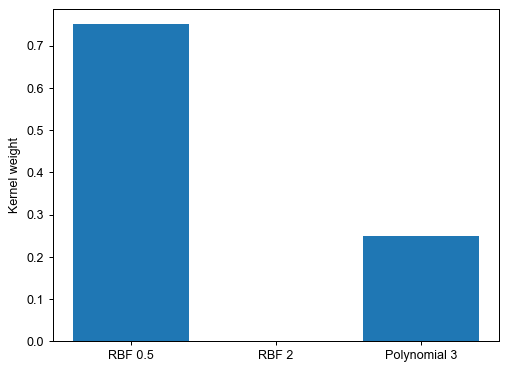

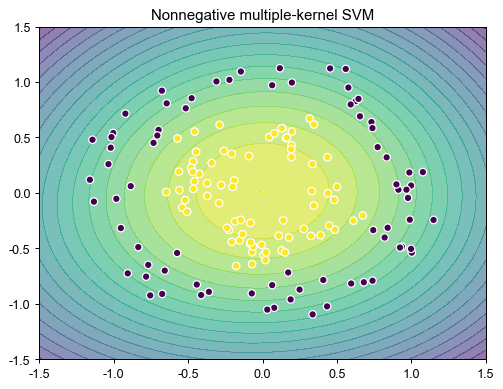

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel
X, y = make_circles(n_samples=600, factor=0.5, noise=0.12, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
# 权重也属于超参数，因此只能用训练集内部的验证集选择。
Xa, Xv, ya, yv = train_test_split(X_train, y_train, stratify=y_train, random_state=7)
kernels = [lambda A, B: rbf_kernel(A, B, gamma=0.5),
           lambda A, B: rbf_kernel(A, B, gamma=2),
           lambda A, B: polynomial_kernel(A, B, degree=3, gamma=1, coef0=1)]
weights = [(a / 4, b / 4, (4-a-b) / 4) for a in range(5) for b in range(5-a)]
records = []
for w in weights:
    K = sum(wi * kernel(Xa, Xa) for wi, kernel in zip(w, kernels))
    Kv = sum(wi * kernel(Xv, Xa) for wi, kernel in zip(w, kernels))
    clf = SVC(kernel='precomputed').fit(K, ya)
    records.append((accuracy_score(yv, clf.predict(Kv)), w))
validation_score, mu = max(records, key=lambda item: item[0])
K = sum(wi * kernel(X_train, X_train) for wi, kernel in zip(mu, kernels))
Kt = sum(wi * kernel(X_test, X_train) for wi, kernel in zip(mu, kernels))
clf = SVC(kernel='precomputed').fit(K, y_train)
print('验证集选择的核权重:', mu, '验证集准确率:', validation_score)
print('独立测试集准确率:', accuracy_score(y_test, clf.predict(Kt)))
plt.bar(['RBF 0.5', 'RBF 2', 'Polynomial 3'], mu)
plt.ylabel('Kernel weight'); plt.show()
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Kg = sum(wi * kernel(grid, X_train) for wi, kernel in zip(mu, kernels))
plt.contourf(xx, yy, clf.decision_function(Kg).reshape(xx.shape), levels=20, alpha=0.6)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='white')
plt.title('Nonnegative multiple-kernel SVM'); plt.show()

## 模型分析

### 多核学习优缺点

**优点**：

1. **融合多个核函数：捕捉复杂数据结构**：本案例使用了多个核（如不同参数的 RBF 核和多项式核），它们分别对不同数据结构具有感知能力。通过学习合适的核组合权重，多核学习可以自动适应数据中的复杂结构，避免手动选择最佳核函数。
2. **模型解释性增强：核权重反映特征偏好**：学到的核权重提供了关于数据分布的有用信息。例如，如果某种核权重更高，表明该核所代表的相似性度量更契合任务本身。这对模型可解释性具有帮助。
3. **模块化强：可扩展至任意核函数族**：多核学习框架天然适配新的核函数加入，只需扩展核集合即可，这种模块化在实际应用中极具灵活性。
4. **提高泛化性能：核选择自动化**：相较于单一核 SVM，自动优化核权重可以减少人为调参，提高模型泛化能力。

**缺点**：

1. **计算成本高：多次 QP 求解与核组合开销大**：每次迭代都需要重新计算组合核矩阵，并求解完整的 SVM 二次规划问题，计算成本远高于传统 SVM。
2. **对超参数敏感：如惩罚因子 C、初始核组合等**：虽然核函数组合权重可以学习，但仍然对如 $C$、$\gamma$、degree 等超参数敏感，这可能影响最终模型质量。
3. **可扩展性差于随机特征法等近似方法**：在大规模样本（如10万+）情况下，由于核矩阵维度为 $n \times n$，内存与计算瓶颈明显，不如线性SVM、核近似方法（如Nystrom、Random Fourier Features）适合大数据场景。

### 多核学习与其他相似算法的对比

| 算法类型 | 是否自动核选择 | 模型复杂性 | 可扩展性 | 优化难度 | 适合任务 |
|-|-|-|-|-|-|
| **单一核SVM** | 否 | 中 | 中等 | 较低 | 数据结构已知，单一核能胜任 |
| **多核学习（MKL）** | 是 | 高 | 差（因核矩阵） | 高 | 数据异质、结构复杂、不确定最优核 |
| **核岭回归（KRR）** | 否 | 中 | 中等 | 较低 | 回归任务，对噪声鲁棒性要求高 |
| **核PCA等无监督核法** | 否 | 中 | 中等 | 中 | 降维、特征提取等无监督场景 |
| **随机特征映射法** | 否 | 中 | 高（近似线性） | 低 | 大规模数据，追求高效近似核学习 |

### 使用多核学习的优选场景

- **数据来源异构或多模态（如图像 + 文本）**：不同类型的核可分别用于不同模态信息的建模，多核学习可融合多模态特征。
- **样本数量中等、特征结构复杂的任务**：如图像识别中具有纹理、边缘、颜色等多种属性的分类问题，不同核函数捕捉不同特征维度。
- **缺乏先验知识，无法手动选择最佳核函数时**：MKL 可以自动根据数据分布学习核权重，省去了核函数选择的试错过程。

### 建议考虑其他算法的场景

- **样本规模极大时（>10万级别）**：建议使用核近似技术（如随机傅里叶特征）、线性SVM等，更节省内存。
- **特征空间结构明确，单一核效果好时**：若已有经验知道 RBF 核或线性核已足够建模，则不必引入额外复杂性。
- **计算资源有限时**：多核学习的迭代求解和矩阵操作对内存与CPU开销较高，不适合嵌入式或实时场景。

### 总结

本案例展示了多核学习在处理复杂非线性任务上的强大能力，特别适合结构复杂或多源数据任务。尽管存在计算成本高的问题，但其自动核选择机制为数据建模带来了极大灵活性。在合理的数据规模和算力下，多核学习是一种非常值得探索的核方法升级路径。